Coletando dados dos logs...
GA - instance-11: 50 execuções coletadas
TS - instance-11: 50 execuções coletadas
GRASP - instance-11: 50 execuções coletadas
GA - instance-13: 50 execuções coletadas
TS - instance-13: 50 execuções coletadas
GRASP - instance-13: 50 execuções coletadas
GA - instance-14: 50 execuções coletadas
TS - instance-14: 50 execuções coletadas
GRASP - instance-14: 50 execuções coletadas


=== Análise de Custos ===

instance-11:
  GA: min=4403.0, mean=4580.8, max=4699.0, median=4598.5
  TS: min=4782.0, mean=4782.0, max=4782.0, median=4782.0
  GRASP: min=4481.0, mean=4667.2, max=4718.0, median=4702.5

instance-13:
  GA: min=8439.0, mean=9426.6, max=9995.0, median=9502.5
  TS: min=13510.0, mean=13522.8, max=13533.0, median=13519.0
  GRASP: min=2726.0, mean=3081.5, max=3528.0, median=3051.0

instance-14:
  GA: min=10297.0, mean=10833.6, max=11800.0, median=10727.0
  TS: min=14904.0, mean=14921.6, max=14922.0, median=14922.0
  GRASP: min=2877.0, mean=3553.7, max=4334.0, medi

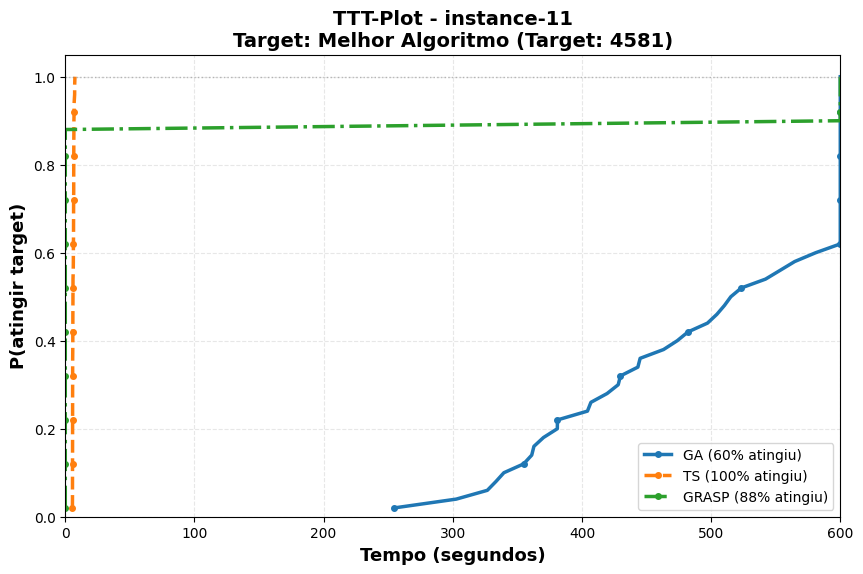

Gráfico salvo: plots/ttt_plot_instance-13_Target:_Melhor_Algoritmo.png


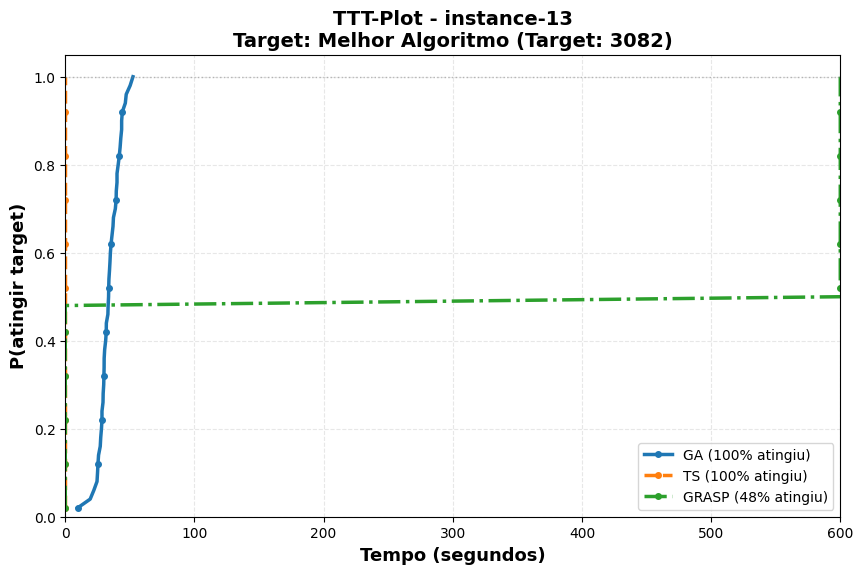

Gráfico salvo: plots/ttt_plot_instance-14_Target:_Melhor_Algoritmo.png


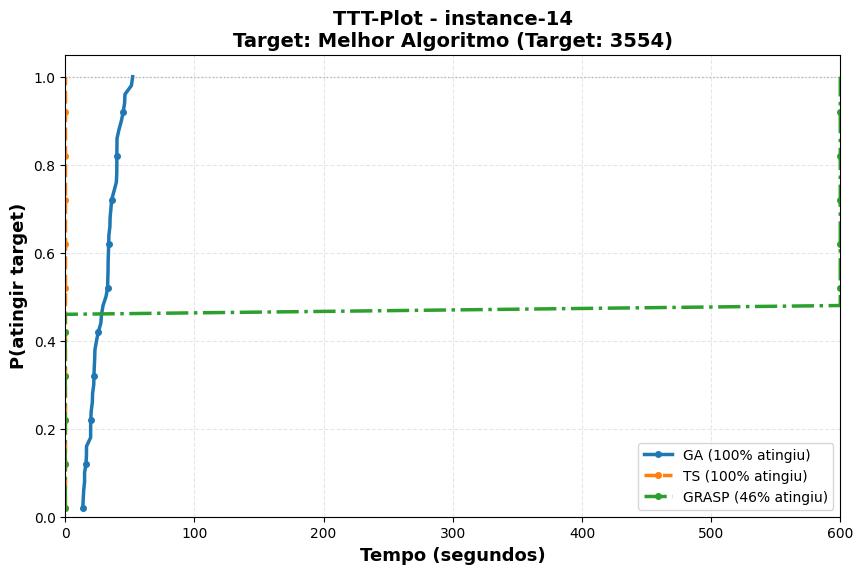


✓ Processo concluído!


In [26]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def parse_log_file(filepath):
    """
    Parseia um arquivo de log e extrai os dados de custo e tempo.
    Retorna uma lista de tuplas (tempo, custo).
    """
    data = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
        
    # Padrão para extrair tempo e custo
    pattern = r'Time:\s*([\d.]+)\).*?cost=\[([\d.]+)\]'
    matches = re.findall(pattern, content)
    
    for time_str, cost_str in matches:
        time = float(time_str)
        cost = float(cost_str)
        data.append((time, cost))
    
    # Adiciona o ponto inicial (geração/iteração 0) se existir
    init_pattern = r'\((?:Gen\.|Iter\.)\s*0(?:\s*\||\))'
    if re.search(init_pattern, content):
        cost_pattern = r'\((?:Gen\.|Iter\.)\s*0.*?cost=\[([\d.]+)\]'
        match = re.search(cost_pattern, content)
        if match:
            initial_cost = float(match.group(1))
            data.insert(0, (0.0, initial_cost))
    
    return data

def collect_all_runs(base_dir, algorithm_dirs, instances):
    """
    Coleta dados de todas as execuções para cada algoritmo e instância.
    
    Retorna: dict[instância][algoritmo] = list de runs
             onde cada run é uma lista de (tempo, custo)
    """
    all_data = {}
    
    for instance in instances:
        all_data[instance] = {}
        
        for alg_name, alg_dir in algorithm_dirs.items():
            runs = []
            alg_path = os.path.join(base_dir, alg_dir)
            
            if not os.path.exists(alg_path):
                print(f"Aviso: Diretório não encontrado: {alg_path}")
                continue
            
            # Lista todos os arquivos que correspondem ao padrão instance-XX_run_Y
            pattern = f"{instance}_run_"
            log_files = sorted([f for f in os.listdir(alg_path) 
                              if f.startswith(pattern) and (f.endswith('.txt') or f.endswith('.log'))])
            
            for log_file in log_files:
                filepath = os.path.join(alg_path, log_file)
                try:
                    run_data = parse_log_file(filepath)
                    if run_data:
                        runs.append(run_data)
                except Exception as e:
                    print(f"Erro ao processar {filepath}: {e}")
            
            all_data[instance][alg_name] = runs
            print(f"{alg_name} - {instance}: {len(runs)} execuções coletadas")
    
    return all_data

def compute_ttt_curve(runs, target_quality, max_time=600):
    """
    Calcula a curva TTT (Time-to-Target) para um conjunto de execuções.
    
    Retorna:
        times: array de tempos
        probabilities: probabilidade acumulada de atingir o target em cada tempo
    """
    times_to_target = []
    
    for run in runs:
        # Encontra o primeiro momento em que o custo >= target_quality
        for time, cost in run:
            if cost >= target_quality:
                times_to_target.append(time)
                break
        else:
            # Se não atingiu o target, considera tempo máximo
            times_to_target.append(max_time)
    
    if not times_to_target:
        return np.array([]), np.array([])
    
    # Ordena os tempos
    times_to_target = np.array(sorted(times_to_target))
    
    # Calcula probabilidade acumulada
    n = len(times_to_target)
    probabilities = np.arange(1, n + 1) / n
    
    return times_to_target, probabilities

def plot_ttt_curves(all_data, instances, target_qualities, output_dir='plots', strategy_name=''):
    """
    Plota as curvas TTT para cada instância.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    colors = {'GA': '#1f77b4', 'TS': '#ff7f0e', 'GRASP': '#2ca02c'}
    linestyles = {'GA': '-', 'TS': '--', 'GRASP': '-.'}
    
    for instance, target in zip(instances, target_qualities):
        plt.figure(figsize=(10, 6))
        
        legend_entries = []
        
        for alg_name in ['GA', 'TS', 'GRASP']:
            if alg_name not in all_data[instance] or not all_data[instance][alg_name]:
                print(f"Aviso: Sem dados para {alg_name} na instância {instance}")
                continue
            
            runs = all_data[instance][alg_name]
            times, probs = compute_ttt_curve(runs, target)
            
            if len(times) > 0:
                # Calcula quantas execuções atingiram o target
                success_count = sum(1 for run in runs 
                                  if any(cost >= target for _, cost in run))
                success_rate = (success_count / len(runs)) * 100
                
                plt.plot(times, probs, 
                        label=f'{alg_name} ({success_rate:.0f}% atingiu)', 
                        color=colors[alg_name],
                        linestyle=linestyles[alg_name],
                        linewidth=2.5,
                        marker='o',
                        markevery=max(1, len(times)//10),
                        markersize=4)
        
        plt.xlabel('Tempo (segundos)', fontsize=13, fontweight='bold')
        plt.ylabel('P(atingir target)', fontsize=13, fontweight='bold')
        
        title = f'TTT-Plot - {instance}'
        if strategy_name:
            title += f'\n{strategy_name} (Target: {target:.0f})'
        else:
            title += f'\nTarget Quality: {target:.0f}'
        
        plt.title(title, fontsize=14, fontweight='bold')
        plt.legend(fontsize=10, loc='lower right')
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 600)
        plt.ylim(0, 1.05)
        
        # Adiciona linha de referência no target
        plt.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        
        # Salva o gráfico
        suffix = f'_{strategy_name.replace(" ", "_")}' if strategy_name else ''
        output_path = os.path.join(output_dir, f'ttt_plot_{instance}{suffix}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Gráfico salvo: {output_path}")
        plt.show()
        plt.close()

def get_best_costs(all_data, instances):
    """
    Analisa os dados e sugere targets baseados nos melhores custos encontrados.
    Retorna um dicionário com sugestões de targets.
    """
    print("\n=== Análise de Custos ===")
    
    suggestions = {}
    
    for instance in instances:
        print(f"\n{instance}:")
        instance_stats = {}
        
        for alg_name in ['GA', 'TS', 'GRASP']:
            if alg_name not in all_data[instance]:
                continue
            
            runs = all_data[instance][alg_name]
            max_costs = []
            
            for run in runs:
                if run:
                    max_cost = max(cost for _, cost in run)
                    max_costs.append(max_cost)
            
            if max_costs:
                instance_stats[alg_name] = {
                    'min': min(max_costs),
                    'mean': np.mean(max_costs),
                    'max': max(max_costs),
                    'median': np.median(max_costs),
                    'q25': np.percentile(max_costs, 25),
                    'q75': np.percentile(max_costs, 75)
                }
                print(f"  {alg_name}: min={instance_stats[alg_name]['min']:.1f}, "
                      f"mean={instance_stats[alg_name]['mean']:.1f}, "
                      f"max={instance_stats[alg_name]['max']:.1f}, "
                      f"median={instance_stats[alg_name]['median']:.1f}")
        
        # Calcula targets sugeridos
        if instance_stats:
            all_means = [stats['mean'] for stats in instance_stats.values()]
            all_medians = [stats['median'] for stats in instance_stats.values()]
            best_mean = min(all_means)
            best_median = min(all_medians)
            worst_mean = max(all_means)
            
            suggestions[instance] = {
                'best_algorithm': best_mean,  # Melhor resultado médio
                'conservative': best_mean * 1.05,  # 5% acima do melhor
                'moderate': np.mean([best_mean, np.median(all_means)]),  # Entre melhor e mediano
                'inclusive': np.percentile(all_means, 75),  # 75% dos algoritmos
                'best_median': best_median
            }
    
    return suggestions

# ============================================
# CONFIGURAÇÃO PRINCIPAL
# ============================================

# Diretório base onde estão os logs
BASE_DIR = ''  # Ajuste conforme sua estrutura

# Mapeamento de algoritmos para diretórios
ALGORITHM_DIRS = {
    'GA': 'logs-ga',
    'TS': 'logs-ts',
    'GRASP': 'logs-grasp'
}

# Lista de instâncias (formato: instance-11, instance-13, instance-14)
INSTANCES = ['instance-11', 'instance-13', 'instance-14']

# Target quality para cada instância (ajuste baseado nos seus dados)
# Você pode usar valores como 90% do melhor custo médio
TARGET_QUALITIES = [4500, 4500, 4500]  # Ajuste esses valores

# ============================================
# EXECUÇÃO
# ============================================

if __name__ == "__main__":
    # Coleta todos os dados
    print("Coletando dados dos logs...")
    all_data = collect_all_runs(BASE_DIR, ALGORITHM_DIRS, INSTANCES)
    
    # Analisa e mostra estatísticas com sugestões
    print("\n" + "="*60)
    suggestions = get_best_costs(all_data, INSTANCES)
    
    # Mostra sugestões de targets
    print("\n" + "="*60)
    print("=== SUGESTÕES DE TARGETS ===")
    print("="*60)
    
    for instance in INSTANCES:
        if instance in suggestions:
            print(f"\n{instance}:")
            print(f"  1. Melhor Algoritmo (favorece o melhor): {suggestions[instance]['best_algorithm']:.0f}")
            print(f"  2. Conservador (+5% melhor): {suggestions[instance]['conservative']:.0f}")
            print(f"  3. Moderado (meio termo): {suggestions[instance]['moderate']:.0f}")
            print(f"  4. Inclusivo (75% dos algoritmos): {suggestions[instance]['inclusive']:.0f}")
    
    print("\n" + "="*60)
    print("RECOMENDAÇÃO: Use a estratégia 'Melhor Algoritmo' para destacar")
    print("o melhor desempenho, ou 'Moderado' para comparação mais justa.")
    print("="*60)
    
    # Escolha a estratégia desejada:
    # Opção 1: Target baseado no melhor algoritmo (recomendado para seus dados)
    strategy = 'best_algorithm'
    strategy_name = 'Target: Melhor Algoritmo'
    
    # Opção 2: Target moderado (descomente para usar)
    # strategy = 'moderate'
    # strategy_name = 'Target: Moderado'
    
    # Opção 3: Target inclusivo (descomente para usar)
    # strategy = 'inclusive'
    # strategy_name = 'Target: Inclusivo'
    
    # Gera os targets automaticamente
    auto_targets = [suggestions[inst][strategy] for inst in INSTANCES]
    
    print(f"\n\nUsando estratégia: {strategy_name}")
    print(f"Targets: {[f'{t:.0f}' for t in auto_targets]}")
    
    # Plota as curvas TTT
    print("\nGerando TTT-plots...")
    plot_ttt_curves(all_data, INSTANCES, auto_targets, strategy_name=strategy_name)
    
    print("\n✓ Processo concluído!")
    # print("\nDica: Teste diferentes estratégias comentando/descomentando")
    # print("as opções na seção 'Escolha a estratégia desejada'.")